In questo esercizio si integra una funzione di prova in diversi modi: con il metodo quad, con il metodo dei trapezi e il metodo di Simpson. Viene mostrata la convergenza dei risultati al variare del numero di punti usati per l’integrazione numerica.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid, simpson, quad  

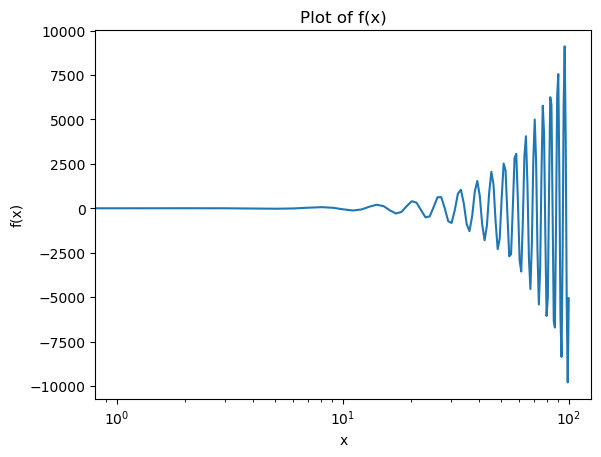

In [2]:
def function(x):
  return x**2 *np.sin(x)

xx=np.linspace(0,100,100) # Crea 100 punti equispaziati tra 0 e 100
fx=function(xx) # Calcola i valori della funzione in xx

plt.semilogx(xx,fx) 
plt.title("Plot of f(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

In [3]:
# Calcola l’integrale con il metodo quad
integral_quad=quad(function,a=1.e-4,b=100,limit=5000) # dove a=lim.inf, b=lim.sup, limit=numero di punti per l'integrazione
integral_quad # Mostra il risultato (valore dell'integrale + errore stimato)

(-8724.737213354323, 0.0001295408054494427)

In [4]:
xx=np.linspace(0,100,10000) # Più punti per aumentare la precisione
fx=function(xx)

# Calcola l'integrale con il metodo trapezoid
integral_trapz=trapezoid(fx,xx)

#Confronta il risultato con quello di quad
integral_trapz,integral_quad[0]

(np.float64(-8724.666183069996), -8724.737213354323)

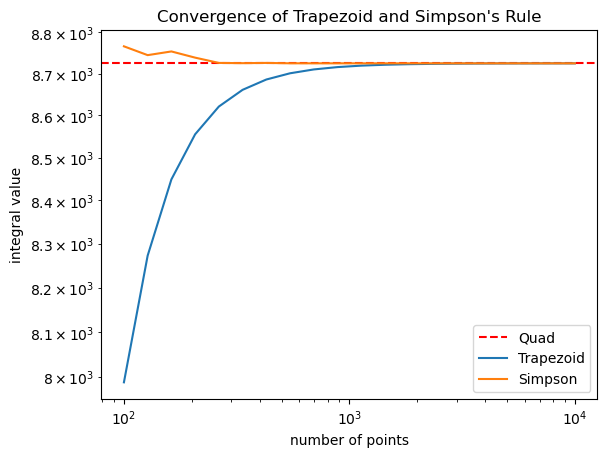

In [5]:
# Plotta una linea orizzontale che rappresenta il valore di riferimento (quad)
plt.axhline(np.abs(integral_quad[0]), color="r", linestyle="--", label="Quad")

list_n=np.logspace(2,4,20)
list_f=[] # Lista per salvare i risultati del metodo trapezoid
list_s=[] # Lista per salvare i risultati del metodo simpson

for n in list_n:
  xx=np.linspace(0,100,int(n))
  fx=function(xx)
  integral_trapz=trapezoid(fx,xx)
  integral_simps=simpson(fx,x=xx) # Calcola l'integrale con il metodo simpson
  list_f.append(integral_trapz)
  list_s.append(integral_simps)

plt.loglog(list_n, np.abs(list_f),label="Trapezoid")
plt.loglog(list_n,np.abs(list_s),label="Simpson")
plt.legend(loc="lower right")
plt.xlabel("number of points")
plt.ylabel("integral value")
plt.title("Convergence of Trapezoid and Simpson's Rule")
plt.show()